<a href="https://colab.research.google.com/github/ihbachghita84-alt/S8_CI_22006636/blob/main/CI_22006213_BOUMAZIANE_CHAIMAA_22006636_IHBACH_GHITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 0. Installation & Imports

In [ ]:
# ── Installation des librairies nécessaires ──────────────────────────────────
!pip install -q xgboost shap imbalanced-learn optuna
print("✅ Librairies installées")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00
✅ Librairies installées


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prétraitement
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

# Interprétabilité
import shap

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Style graphique
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#2ECC71', '#F39C12', '#E74C3C']

print("✅ Imports réussis")

✅ Imports réussis


---
## 1. Génération du Dataset P2P Simulé

> **Note :** Ce dataset simule un processus Procure-to-Pay réel, aligné sur le dataset Kaggle *Purchase Order Fraud*.  
> Si vous disposez du vrai fichier Kaggle, remplacez la cellule de génération par `df = pd.read_csv('votre_fichier.csv')`.

In [ ]:
def generate_p2p_dataset(n=45211, seed=SEED):
    """
    Génère un dataset P2P (Procure-to-Pay) simulé avec 3 classes :
      0 = Normale (85%), 1 = Suspecte (12%), 2 = Frauduleuse (3%)
    Les features sont calibrées pour reproduire les patterns de fraude
    identifiés dans la littérature d'audit (ACFE, COSO).
    """
    rng = np.random.default_rng(seed)

    # ── Proportions des classes ──────────────────────────────────────────────
    n_normal    = int(n * 0.85)   # 38 429
    n_suspect   = int(n * 0.12)   #  5 425
    n_fraud     = n - n_normal - n_suspect  #  1 357
    labels      = ([0]*n_normal + [1]*n_suspect + [2]*n_fraud)

    records = []

    # ── Paramètres par classe ────────────────────────────────────────────────
    params = {
        0: dict(  # NORMALE
            montant_mu=5000,   montant_sig=3000,
            anciennete_mu=700, anciennete_sig=300,
            delai_mu=12,       delai_sig=5,
            ratio_mu=1.00,     ratio_sig=0.05,
            freq_mu=3,         freq_sig=1.5,
            p_self_approval=0.01,
            p_receipt_missing=0.03,
            p_doublon=0.005,
            p_near_threshold=0.02,
            p_endperiod=0.10,
        ),
        1: dict(  # SUSPECTE
            montant_mu=4500,   montant_sig=4000,
            anciennete_mu=200, anciennete_sig=150,
            delai_mu=6,        delai_sig=4,
            ratio_mu=1.08,     ratio_sig=0.10,
            freq_mu=6,         freq_sig=3,
            p_self_approval=0.08,
            p_receipt_missing=0.15,
            p_doublon=0.05,
            p_near_threshold=0.15,
            p_endperiod=0.22,
        ),
        2: dict(  # FRAUDULEUSE
            montant_mu=8000,   montant_sig=15000,
            anciennete_mu=45,  anciennete_sig=30,
            delai_mu=2,        delai_sig=2,
            ratio_mu=1.20,     ratio_sig=0.15,
            freq_mu=12,        freq_sig=5,
            p_self_approval=0.35,
            p_receipt_missing=0.55,
            p_doublon=0.20,
            p_near_threshold=0.40,
            p_endperiod=0.38,
        ),
    }

    categories = ['IT', 'Fournitures', 'Services', 'Maintenance', 'Logistique', 'RH', 'Marketing']
    localisation = ['France', 'Maroc', 'Espagne', 'Allemagne', 'UK', 'Offshore']

    for lbl in labels:
        p = params[lbl]

        # Montant — fraude : bimodale (fractionnement + montant élevé)
        if lbl == 2 and rng.random() < 0.40:
            # Pic fractionnement : juste sous le seuil de 1000€
            montant = max(50, rng.normal(920, 60))
        else:
            montant = max(50, rng.normal(p['montant_mu'], p['montant_sig']))

        anciennete   = max(1,  int(rng.normal(p['anciennete_mu'],  p['anciennete_sig'])))
        delai_appro  = max(0,  int(rng.normal(p['delai_mu'],       p['delai_sig'])))
        ratio_fac    = max(0.5, rng.normal(p['ratio_mu'],          p['ratio_sig']))
        freq_30j     = max(1,  int(rng.normal(p['freq_mu'],        p['freq_sig'])))

        self_approval    = int(rng.random() < p['p_self_approval'])
        receipt_missing  = int(rng.random() < p['p_receipt_missing'])
        doublon_facture  = int(rng.random() < p['p_doublon'])
        near_threshold   = int(rng.random() < p['p_near_threshold'])
        fin_periode      = int(rng.random() < p['p_endperiod'])

        n_approbations   = max(1, int(rng.normal(2 - lbl * 0.5, 0.8)))
        delai_paiement   = max(0, int(rng.normal(30 - lbl * 8,  10)))
        score_risque_frs = round(min(1.0, max(0.0, rng.normal(0.1 + lbl * 0.3, 0.15))), 3)

        records.append({
            # Identifiants
            'commande_id':          f'PO-{rng.integers(10000, 99999)}',
            # Features numériques
            'montant_commande':     round(montant, 2),
            'anciennete_frs_jours': anciennete,
            'delai_approbation_j':  delai_appro,
            'ratio_facture_cmd':    round(ratio_fac, 4),
            'freq_commande_30j':    freq_30j,
            'n_approbations':       n_approbations,
            'delai_paiement_j':     delai_paiement,
            'score_risque_frs':     score_risque_frs,
            # Features binaires / catégorielles
            'self_approval':        self_approval,
            'receipt_missing':      receipt_missing,
            'doublon_facture':      doublon_facture,
            'near_threshold':       near_threshold,
            'fin_periode':          fin_periode,
            'categorie_produit':    rng.choice(categories),
            'localisation_frs':     rng.choice(localisation),
            # Cible
            'statut':               lbl,
        })

    df = pd.DataFrame(records)
    # Shuffle
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


df = generate_p2p_dataset()

print(f"✅ Dataset généré : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print("\n📊 Distribution des classes :")
dist = df['statut'].value_counts().sort_index()
labels_map = {0: 'Normale', 1: 'Suspecte', 2: 'Frauduleuse'}
for k, v in dist.items():
    print(f"  {labels_map[k]:12s} ({k}) : {v:5d}  ({v/len(df)*100:.1f}%)")
df.drop(columns='commande_id').head(5)

✅ Dataset généré : 45,211 lignes × 17 colonnes

📊 Distribution des classes :
  Normale      (0) : 38429  (85.0%)
  Suspecte     (1) :  5425  (12.0%)
  Frauduleuse  (2) :  1357  (3.0%)


,montant_commande,anciennete_frs_jours,delai_approbation_j,ratio_facture_cmd,freq_commande_30j,n_approbations,delai_paiement_j,score_risque_frs,self_approval,receipt_missing,doublon_facture,near_threshold,fin_periode,categorie_produit,localisation_frs,statut
0,3463.36,726,4,1.0284,2,1,25,0.000,0,0,0,0,0,Fournitures,Offshore,0
1,5200.53,542,11,1.0435,1,2,31,0.086,0,0,0,0,0,RH,UK,0
2,4533.71,30,19,1.0904,2,1,24,0.060,0,0,0,0,1,Fournitures,Allemagne,0
3,3326.68,515,1,1.0415,4,2,31,0.056,0,0,0,0,0,IT,France,0
4,6300.40,479,10,1.1014,3,3,30,0.063,0,0,0,1,0,Marketing,Espagne,0


---
## 2. 🔍 Exploration des Données (EDA)

In [ ]:
# ── 2.1 Statistiques descriptives ────────────────────────────────────────────
print("📋 Statistiques descriptives (variables numériques) :")
df.drop(columns='commande_id').describe().round(2)

📋 Statistiques descriptives (variables numériques) :


,montant_commande,anciennete_frs_jours,delai_approbation_j,ratio_facture_cmd,freq_commande_30j,n_approbations,delai_paiement_j,score_risque_frs,self_approval,receipt_missing,doublon_facture,near_threshold,fin_periode,statut
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,5073.65,619.51,10.49,1.02,3.23,1.57,28.03,0.17,0.03,0.06,0.02,0.05,0.12,0.18
std,3437.49,336.08,5.37,0.08,2.49,0.68,10.65,0.18,0.17,0.24,0.13,0.21,0.33,0.46
min,50.00,1.00,0.00,0.73,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2730.35,368.00,7.00,0.97,2.00,1.00,21.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00
50%,4870.73,632.00,11.00,1.01,3.00,1.00,28.00,0.13,0.00,0.00,0.00,0.00,0.00,0.00
75%,7055.34,860.00,14.00,1.05,4.00,2.00,35.00,0.26,0.00,0.00,0.00,0.00,0.00,0.00
max,60208.74,1920.00,33.00,1.79,28.00,4.00,72.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00


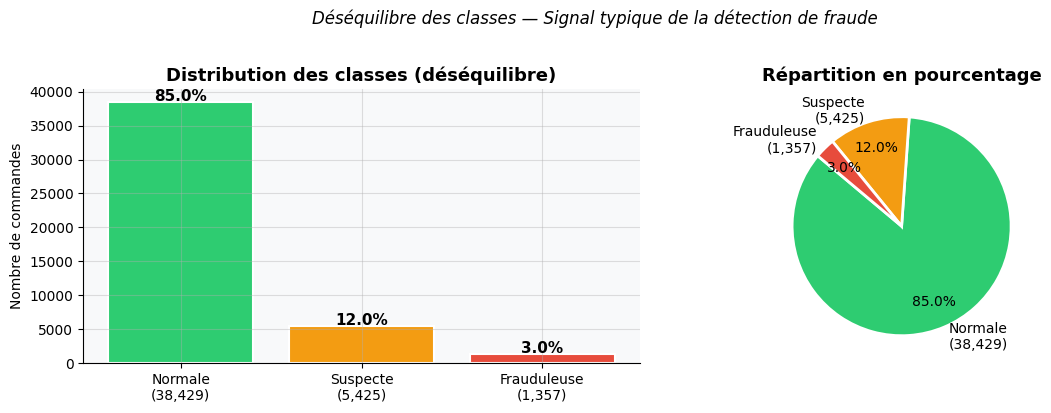

In [ ]:
# ── 2.2 Distribution des classes ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['statut'].value_counts().sort_index()
classe_labels = [f"{labels_map[i]}\n({counts[i]:,})" for i in sorted(counts.index)]

# Barplot
bars = axes[0].bar(classe_labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/len(df)*100:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribution des classes (déséquilibre)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de commandes')

# Pie chart
axes[1].pie(counts.values, labels=classe_labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition en pourcentage', fontsize=13, fontweight='bold')

plt.suptitle('Déséquilibre des classes — Signal typique de la détection de fraude',
             fontsize=12, style='italic', y=1.02)
plt.tight_layout()
plt.show()

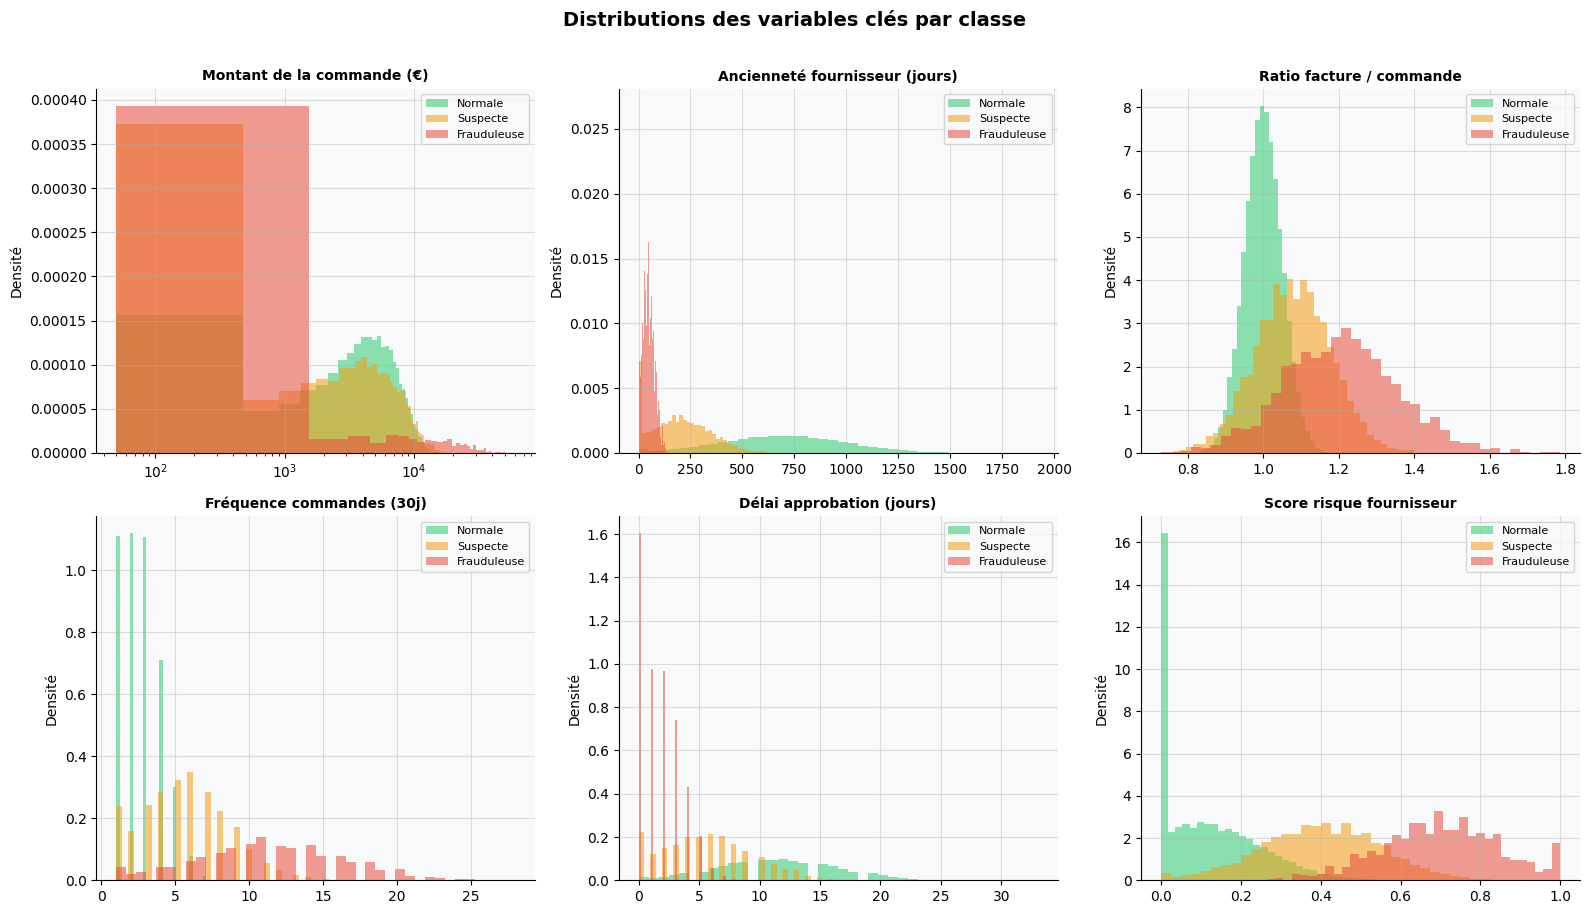

In [ ]:
# ── 2.3 Distributions des variables clés par classe ──────────────────────────
features_plot = [
    ('montant_commande',     'Montant de la commande (€)',    True),
    ('anciennete_frs_jours', 'Ancienneté fournisseur (jours)',False),
    ('ratio_facture_cmd',    'Ratio facture / commande',      False),
    ('freq_commande_30j',    'Fréquence commandes (30j)',     False),
    ('delai_approbation_j',  'Délai approbation (jours)',     False),
    ('score_risque_frs',     'Score risque fournisseur',      False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title, logscale) in zip(axes, features_plot):
    for lbl, color in zip([0, 1, 2], PALETTE):
        data = df[df['statut'] == lbl][col]
        ax.hist(data, bins=40, alpha=0.55, color=color,
                label=labels_map[lbl], edgecolor='none', density=True)
    if logscale:
        ax.set_xscale('log')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Densité')

plt.suptitle('Distributions des variables clés par classe',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

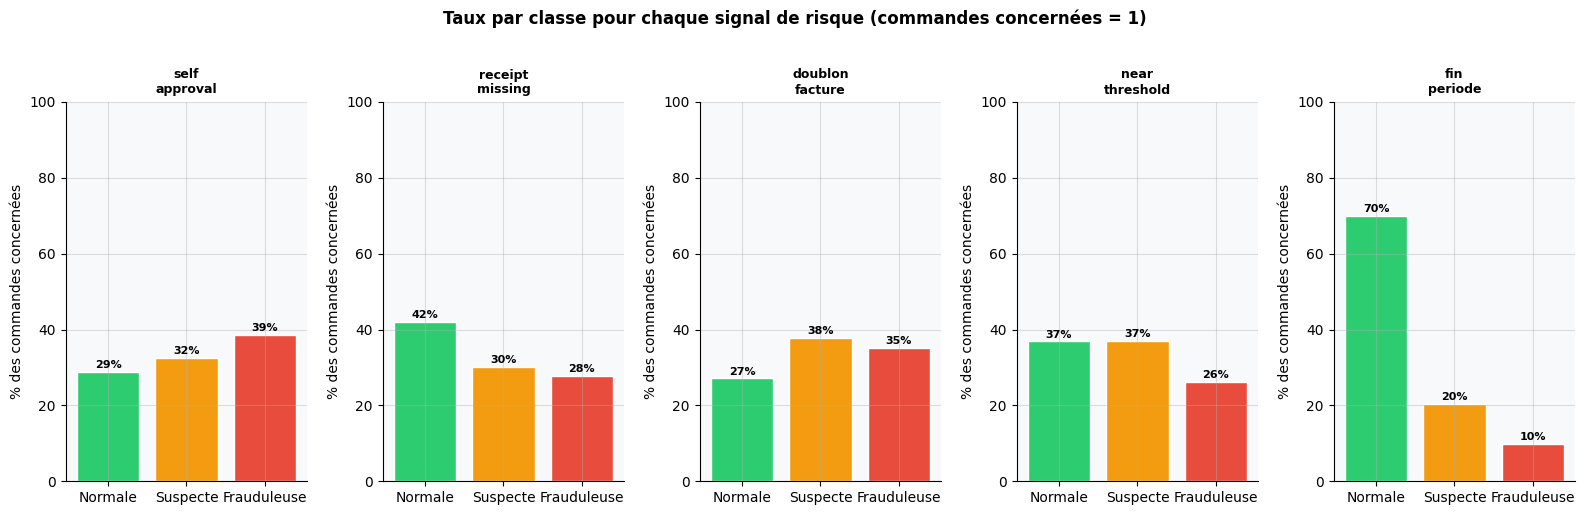

In [ ]:
# ── 2.4 Variables binaires — Taux de fraude ───────────────────────────────────
binary_features = [
    'self_approval', 'receipt_missing', 'doublon_facture',
    'near_threshold', 'fin_periode'
]

fig, axes = plt.subplots(1, len(binary_features), figsize=(16, 5))

for ax, feat in zip(axes, binary_features):
    rates = df[df[feat] == 1]['statut'].value_counts(normalize=True).sort_index() * 100
    rates_all = pd.Series([0.0]*3, index=[0,1,2])
    for k in rates.index:
        rates_all[k] = rates[k]
    bars = ax.bar([labels_map[i] for i in [0,1,2]], rates_all.values,
                  color=PALETTE, edgecolor='white')
    ax.set_title(feat.replace('_', '\n'), fontweight='bold', fontsize=9)
    ax.set_ylabel('% des commandes concernées')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, rates_all.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Taux par classe pour chaque signal de risque (commandes concernées = 1)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── 2.5 Matrice de corrélation (variables numériques) ─────────────────────────
num_cols = [
    'montant_commande','anciennete_frs_jours','delai_approbation_j',
    'ratio_facture_cmd','freq_commande_30j','n_approbations',
    'delai_paiement_j','score_risque_frs','statut'
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Matrice de corrélation — Variables numériques vs Statut',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Corrélations avec la variable cible (|r| > 0.05) :")
corr_target = corr['statut'].drop('statut').abs().sort_values(ascending=False)
for feat, val in corr_target[corr_target > 0.05].items():
    direction = '🔺' if corr['statut'][feat] > 0 else '🔻'
    print(f"  {direction} {feat:28s} : r = {corr['statut'][feat]:+.3f}")

---
## 3. Prétraitement des Données

In [ ]:
# ── 3.1 Préparation des features ──────────────────────────────────────────────

# Suppression de l'identifiant
df_model = df.drop(columns='commande_id').copy()

# Encodage des variables catégorielles (LabelEncoding)
cat_cols = ['categorie_produit', 'localisation_frs']
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  LabelEncoding [{col}] : {le.classes_}")

# Séparation features / cible
FEATURE_COLS = [c for c in df_model.columns if c != 'statut']
X = df_model[FEATURE_COLS].values
y = df_model['statut'].values

print(f"\n✅ Features : {len(FEATURE_COLS)} colonnes")
print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")

  LabelEncoding [categorie_produit] : [np.str_('Fournitures') np.str_('IT') np.str_('Logistique')
 np.str_('Maintenance') np.str_('Marketing') np.str_('RH')
 np.str_('Services')]
  LabelEncoding [localisation_frs] : [np.str_('Allemagne') np.str_('Espagne') np.str_('France')
 np.str_('Maroc') np.str_('Offshore') np.str_('UK')]

✅ Features : 15 colonnes
   X shape : (45211, 15)
   y shape : (45211,)


In [ ]:
# ── 3.2 Split Train / Validation / Test ───────────────────────────────────────

# 70% train+val / 15% validation / 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765,  # ≈ 15% du total
    random_state=SEED, stratify=y_trainval
)

print("📐 Partitionnement des données :")
for name, ys in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f"  {name:12s}: {len(ys):6,} lignes  |", end="")
    unique, counts = np.unique(ys, return_counts=True)
    for lbl, cnt in zip(unique, counts):
        print(f"  {labels_map[lbl]}: {cnt:4d} ({cnt/len(ys)*100:.1f}%)", end="")
    print()

📐 Partitionnement des données :
  Train       : 31,646 lignes  |  Normale: 26899 (85.0%)  Suspecte: 3797 (12.0%)  Frauduleuse:  950 (3.0%)
  Validation  :  6,783 lignes  |  Normale: 5765 (85.0%)  Suspecte:  814 (12.0%)  Frauduleuse:  204 (3.0%)
  Test        :  6,782 lignes  |  Normale: 5765 (85.0%)  Suspecte:  814 (12.0%)  Frauduleuse:  203 (3.0%)


In [ ]:
# ── 3.3 SMOTE (sur le train uniquement) ──────────────────────────────────────

# Ratio cible après SMOTE : Normale 50%, Suspecte 30%, Frauduleuse 20%
n_normal_target  = int(len(y_train) * 0.50)
n_suspect_target = int(len(y_train) * 0.30)
n_fraud_target   = int(len(y_train) * 0.20)

# SMOTE avec stratégie personnalisée
smote = SMOTE(
    sampling_strategy={1: n_suspect_target, 2: n_fraud_target},
    k_neighbors=5,
    random_state=SEED
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("✅ Après SMOTE (train uniquement) :")
unique, counts = np.unique(y_train_res, return_counts=True)
for lbl, cnt in zip(unique, counts):
    print(f"  {labels_map[lbl]:12s}: {cnt:6,}  ({cnt/len(y_train_res)*100:.1f}%)")
print(f"  Total       : {len(y_train_res):6,}")

✅ Après SMOTE (train uniquement) :
  Normale     : 26,899  (63.0%)
  Suspecte    :  9,493  (22.2%)
  Frauduleuse :  6,329  (14.8%)
  Total       : 42,721


In [ ]:
# ── 3.4 Normalisation (StandardScaler) ───────────────────────────────────────

scaler = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_res)  # fit sur train seulement
X_val_sc    = scaler.transform(X_val)
X_test_sc   = scaler.transform(X_test)

print("✅ Normalisation (z-score) appliquée")
print(f"   Moyenne post-scaling (train) : {X_train_sc.mean():.4f}  (cible : 0)")
print(f"   Écart-type post-scaling      : {X_train_sc.std():.4f}   (cible : 1)")

✅ Normalisation (z-score) appliquée
   Moyenne post-scaling (train) : 0.0000  (cible : 0)
   Écart-type post-scaling      : 1.0000   (cible : 1)


---
## 4. Modélisation

Trois modèles sont entraînés et comparés :
| Modèle | Paradigme | Interprétabilité |
|---|---|---|
| Régression Logistique | Linéaire (baseline) | ✅ Très haute (coefficients) |
| Random Forest | Ensemble (bagging) | 🟡 Moyenne (feature importance) |
| **XGBoost** | Ensemble (boosting) | 🟡 Moyenne → ✅ avec SHAP |

In [ ]:
# ── 4.1 Régression Logistique (Baseline) ─────────────────────────────────────

lr = LogisticRegression(
    multi_class='ovr',
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)
lr.fit(X_train_sc, y_train_res)

y_pred_lr = lr.predict(X_test_sc)

print("📊 RÉGRESSION LOGISTIQUE — Rapport de classification (jeu de test) :")
print(classification_report(y_test, y_pred_lr,
                             target_names=[labels_map[i] for i in [0,1,2]]))

📊 RÉGRESSION LOGISTIQUE — Rapport de classification (jeu de test) :
              precision    recall  f1-score   support

     Normale       1.00      0.97      0.98      5765
    Suspecte       0.81      0.94      0.87       814
 Frauduleuse       0.92      0.93      0.92       203

    accuracy                           0.97      6782
   macro avg       0.91      0.95      0.93      6782
weighted avg       0.97      0.97      0.97      6782



In [ ]:
# ── 4.2 Random Forest ────────────────────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)
# RF n'a pas besoin des données normalisées (mais ici on les utilise pour
# garder la cohérence du pipeline)
rf.fit(X_train_sc, y_train_res)

y_pred_rf = rf.predict(X_test_sc)

print("📊 RANDOM FOREST — Rapport de classification (jeu de test) :")
print(classification_report(y_test, y_pred_rf,
                             target_names=[labels_map[i] for i in [0,1,2]]))

📊 RANDOM FOREST — Rapport de classification (jeu de test) :
              precision    recall  f1-score   support

     Normale       0.99      0.98      0.99      5765
    Suspecte       0.88      0.93      0.91       814
 Frauduleuse       0.97      0.95      0.96       203

    accuracy                           0.98      6782
   macro avg       0.95      0.96      0.95      6782
weighted avg       0.98      0.98      0.98      6782



In [ ]:
# ── 4.3 XGBoost ───────────────────────────────────────────────────────────────

# Calcul des poids par classe pour gérer le déséquilibre
class_counts = np.bincount(y_train_res)
total = len(y_train_res)
sample_weight = np.array([total / (3 * class_counts[c]) for c in y_train_res])

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    use_label_encoder=False,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    random_state=SEED,
    verbosity=0
)

xgb.fit(
    X_train_sc, y_train_res,
    sample_weight=sample_weight,
    eval_set=[(X_val_sc, y_val)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test_sc)

print("📊 XGBOOST — Rapport de classification (jeu de test) :")
print(classification_report(y_test, y_pred_xgb,
                             target_names=[labels_map[i] for i in [0,1,2]]))

📊 XGBOOST — Rapport de classification (jeu de test) :
              precision    recall  f1-score   support

     Normale       0.99      0.99      0.99      5765
    Suspecte       0.92      0.94      0.93       814
 Frauduleuse       0.96      0.97      0.97       203

    accuracy                           0.98      6782
   macro avg       0.96      0.97      0.96      6782
weighted avg       0.98      0.98      0.98      6782



---
## 5. Évaluation & Comparaison des Modèles

In [ ]:
# ── 5.1 Tableau comparatif ────────────────────────────────────────────────────

def get_metrics(y_true, y_pred, model_name):
    """Extrait les métriques clés pour la classe Frauduleuse (classe 2)."""
    from sklearn.metrics import precision_score, recall_score
    return {
        'Modèle': model_name,
        'Accuracy':        f"{(y_true == y_pred).mean()*100:.1f}%",
        'Précision (Fraud.)': f"{precision_score(y_true, y_pred, labels=[2], average='macro')*100:.1f}%",
        'Rappel (Fraud.)': f"{recall_score(y_true, y_pred, labels=[2], average='macro')*100:.1f}%",
        'F1-Score (Fraud.)':  f"{f1_score(y_true, y_pred, labels=[2], average='macro')*100:.1f}%",
        'F1 Pondéré':      f"{f1_score(y_true, y_pred, average='weighted')*100:.1f}%",
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr,  'Régression Logistique'),
    get_metrics(y_test, y_pred_rf,  'Random Forest'),
    get_metrics(y_test, y_pred_xgb, 'XGBoost ✅'),
])

print("═" * 80)
print("  TABLEAU COMPARATIF DES PERFORMANCES — Jeu de test")
print("═" * 80)
print(results.to_string(index=False))
print("═" * 80)
print("\n💡 XGBoost sélectionné comme modèle final (meilleur F1 et Rappel sur Fraude)")

════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF DES PERFORMANCES — Jeu de test
════════════════════════════════════════════════════════════════════════════════
               Modèle Accuracy Précision (Fraud.) Rappel (Fraud.) F1-Score (Fraud.) F1 Pondéré
Régression Logistique    96.7%              91.7%           93.1%             92.4%      96.8%
        Random Forest    97.7%              97.0%           94.6%             95.8%      97.8%
            XGBoost ✅    98.3%              96.1%           97.0%             96.6%      98.3%
════════════════════════════════════════════════════════════════════════════════

💡 XGBoost sélectionné comme modèle final (meilleur F1 et Rappel sur Fraude)


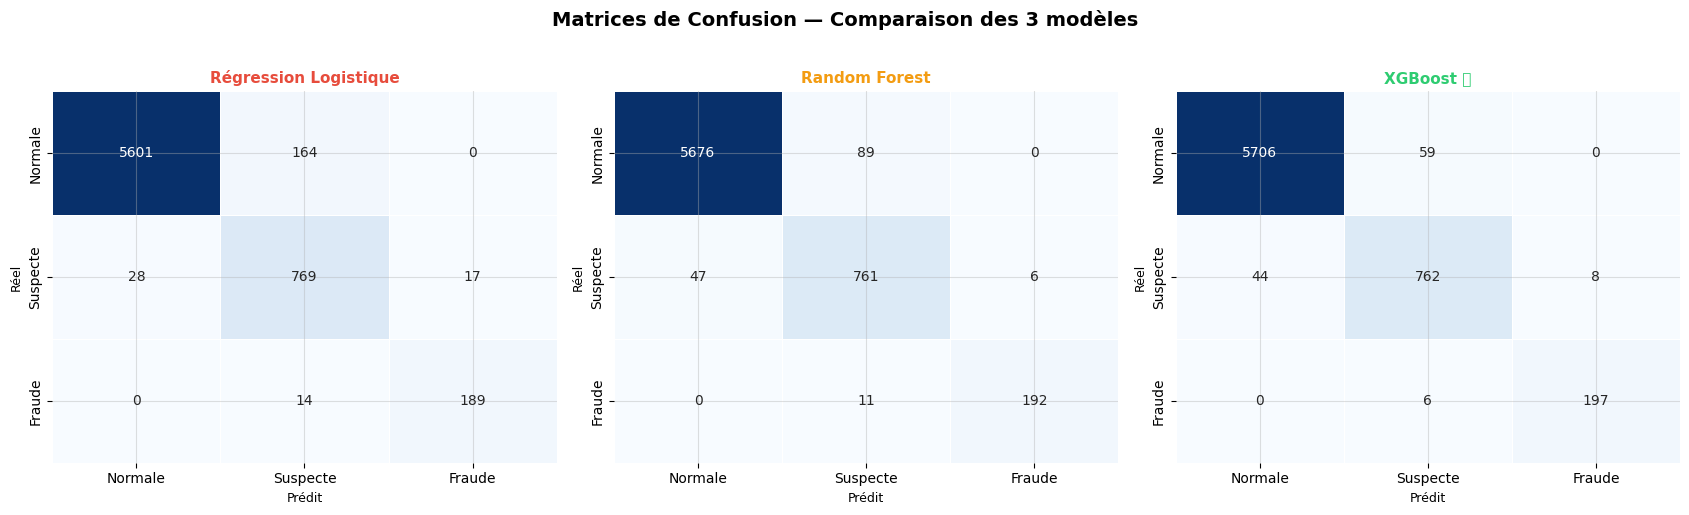

In [ ]:
# ── 5.2 Matrices de confusion ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
models_info = [
    ('Régression Logistique', y_pred_lr,  '#E74C3C'),
    ('Random Forest',         y_pred_rf,  '#F39C12'),
    ('XGBoost ✅',            y_pred_xgb, '#2ECC71'),
]
class_names = ['Normale', 'Suspecte', 'Fraude']

for ax, (name, y_pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Prédit', fontsize=9)
    ax.set_ylabel('Réel', fontsize=9)

plt.suptitle('Matrices de Confusion — Comparaison des 3 modèles',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

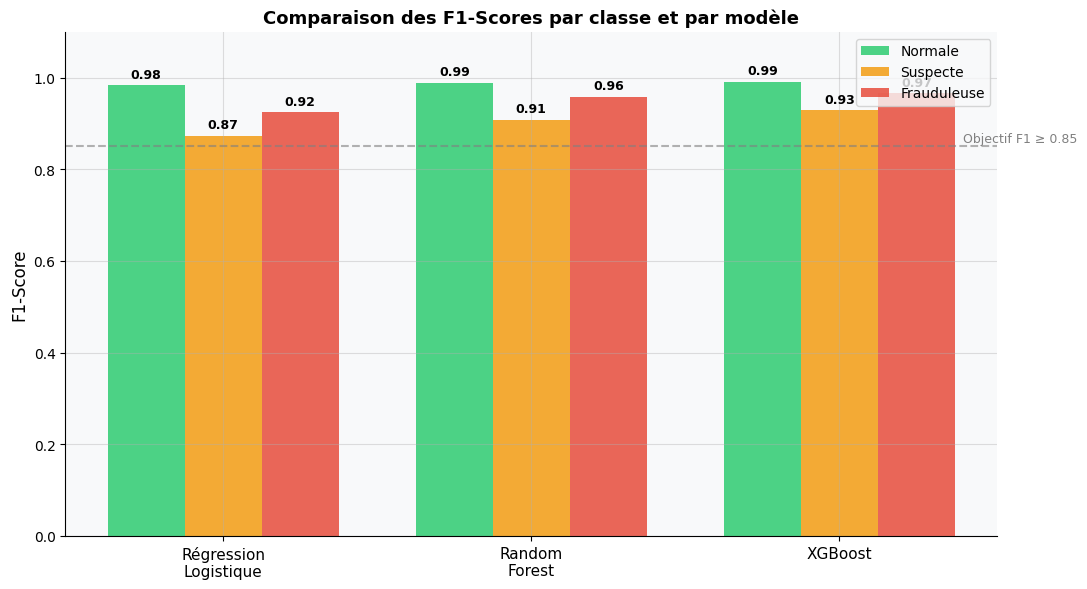

In [ ]:
# ── 5.3 Graphique comparatif des F1-Scores ────────────────────────────────────

model_names = ['Régression\nLogistique', 'Random\nForest', 'XGBoost']

f1_normal   = [f1_score(y_test, yp, labels=[0], average='macro') for yp in [y_pred_lr, y_pred_rf, y_pred_xgb]]
f1_suspect  = [f1_score(y_test, yp, labels=[1], average='macro') for yp in [y_pred_lr, y_pred_rf, y_pred_xgb]]
f1_fraud    = [f1_score(y_test, yp, labels=[2], average='macro') for yp in [y_pred_lr, y_pred_rf, y_pred_xgb]]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width, f1_normal,  width, label='Normale',     color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x,         f1_suspect, width, label='Suspecte',    color=PALETTE[1], alpha=0.85)
b3 = ax.bar(x + width, f1_fraud,   width, label='Frauduleuse', color=PALETTE[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison des F1-Scores par classe et par modèle',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.85, color='grey', linestyle='--', alpha=0.6, label='Objectif (0.85)')
ax.text(2.4, 0.86, 'Objectif F1 ≥ 0.85', fontsize=9, color='grey')

plt.tight_layout()
plt.show()

---
## 6. Interprétabilité avec SHAP

> SHAP (SHapley Additive exPlanations) permet d'expliquer chaque prédiction  
> en quantifiant la contribution de chaque variable à la décision du modèle.

In [ ]:
# ── 6.1 Calcul des valeurs SHAP (XGBoost) ────────────────────────────────────

print("⏳ Calcul des valeurs SHAP (peut prendre 1-2 min)...")
explainer   = shap.TreeExplainer(xgb)

# Utiliser un sous-échantillon pour la rapidité (500 exemples)
idx_sample  = np.random.choice(len(X_test_sc), size=500, replace=False)
X_shap      = X_test_sc[idx_sample]
shap_values = explainer.shap_values(X_shap)  # shape: (n_samples, n_features, n_classes)

# Valeurs SHAP pour la classe Frauduleuse (classe 2)
shap_fraud  = shap_values[:, :, 2]  # ou shap_values[2] selon la version SHAP

print(f"✅ SHAP calculé sur {len(X_shap)} exemples")
print(f"   Shape shap_values : {np.array(shap_values).shape}")

⏳ Calcul des valeurs SHAP (peut prendre 1-2 min)...
✅ SHAP calculé sur 500 exemples
   Shape shap_values : (500, 15, 3)


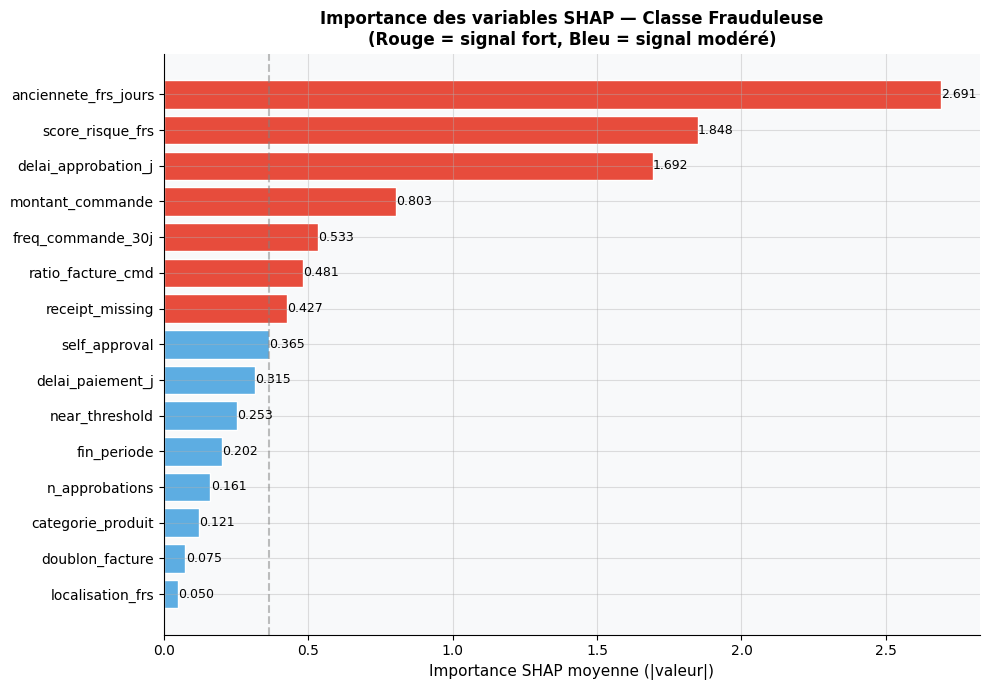

In [ ]:
# ── 6.2 Importance globale des features (classe Frauduleuse) ──────────────────

mean_shap = np.abs(shap_fraud).mean(axis=0)
shap_df = pd.DataFrame({'Feature': FEATURE_COLS, 'SHAP_mean': mean_shap})\
            .sort_values('SHAP_mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v > shap_df['SHAP_mean'].median() else '#5DADE2'
          for v in shap_df['SHAP_mean']]
bars = ax.barh(shap_df['Feature'], shap_df['SHAP_mean'], color=colors, edgecolor='white')

for bar, val in zip(bars, shap_df['SHAP_mean']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importance SHAP moyenne (|valeur|)', fontsize=11)
ax.set_title('Importance des variables SHAP — Classe Frauduleuse\n'
             '(Rouge = signal fort, Bleu = signal modéré)',
             fontsize=12, fontweight='bold')
ax.axvline(shap_df['SHAP_mean'].median(), color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

📊 Summary Plot SHAP (classe Frauduleuse) :


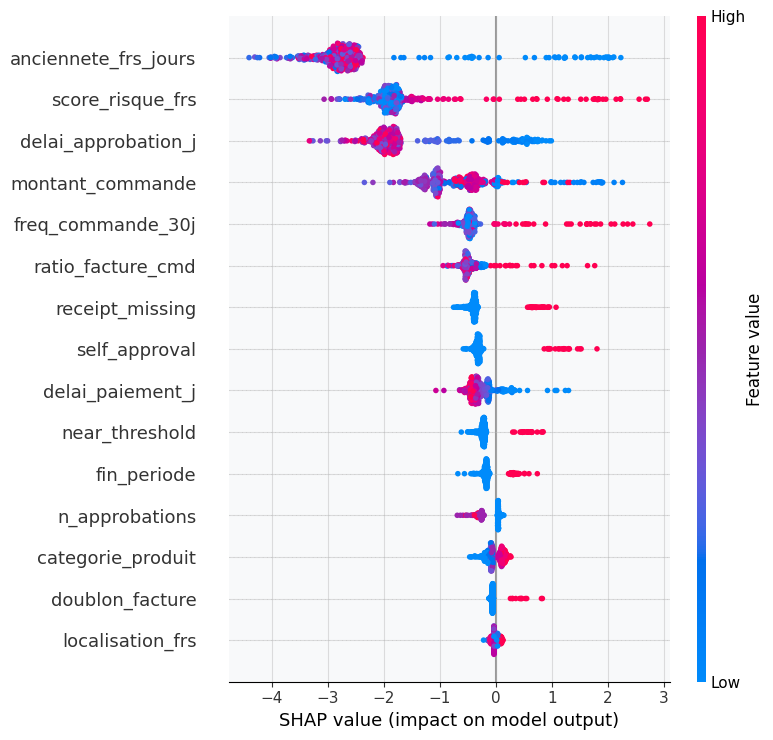

In [ ]:
# ── 6.3 Beeswarm / Summary plot SHAP ─────────────────────────────────────────

print("📊 Summary Plot SHAP (classe Frauduleuse) :")
shap.summary_plot(
    shap_fraud,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    max_display=15,
    show=True
)

In [ ]:
# ── 6.4 Explication d'une commande individuelle frauduleuse ───────────────────

# Trouver un vrai positif (fraude réelle détectée comme fraude)
fraud_indices_test = np.where((y_test == 2) & (y_pred_xgb == 2))[0]

if len(fraud_indices_test) > 0:
    idx = fraud_indices_test[0]
    print("🔴 Explication SHAP d'une commande Frauduleuse correctement détectée :")
    print("-" * 60)
    print("Valeurs des features pour cette commande :")
    for feat, val in zip(FEATURE_COLS, X_test_sc[idx]):
        orig_val = scaler.inverse_transform([X_test_sc[idx]])[0]
        orig_dict = dict(zip(FEATURE_COLS, orig_val))
        print(f"  {feat:28s} = {orig_dict[feat]:.3f}")

    print(f"\n  Probabilités prédites :")
    proba = xgb.predict_proba(X_test_sc[idx:idx+1])[0]
    for lbl, p in zip([labels_map[i] for i in [0,1,2]], proba):
        bar = '█' * int(p * 30)
        print(f"  {lbl:12s}: {p:.2%}  {bar}")
    print(f"\n  ➜ Classe prédite : {labels_map[y_pred_xgb[idx]]}  |  Classe réelle : {labels_map[y_test[idx]]}")
else:
    print("Aucun vrai positif trouvé dans cet échantillon — relancez avec un autre seed.")

🔴 Explication SHAP d'une commande Frauduleuse correctement détectée :
------------------------------------------------------------
Valeurs des features pour cette commande :
  montant_commande             = 849.500
  anciennete_frs_jours         = 3.000
  delai_approbation_j          = 0.000
  ratio_facture_cmd            = 1.286
  freq_commande_30j            = 10.000
  n_approbations               = 1.000
  delai_paiement_j             = 23.000
  score_risque_frs             = 0.722
  self_approval                = 0.000
  receipt_missing              = 1.000
  doublon_facture              = 0.000
  near_threshold               = 0.000
  fin_periode                  = 1.000
  categorie_produit            = 1.000
  localisation_frs             = 0.000

  Probabilités prédites :
  Normale     : 0.00%  
  Suspecte    : 0.01%  
  Frauduleuse : 99.99%  █████████████████████████████

  ➜ Classe prédite : Frauduleuse  |  Classe réelle : Frauduleuse


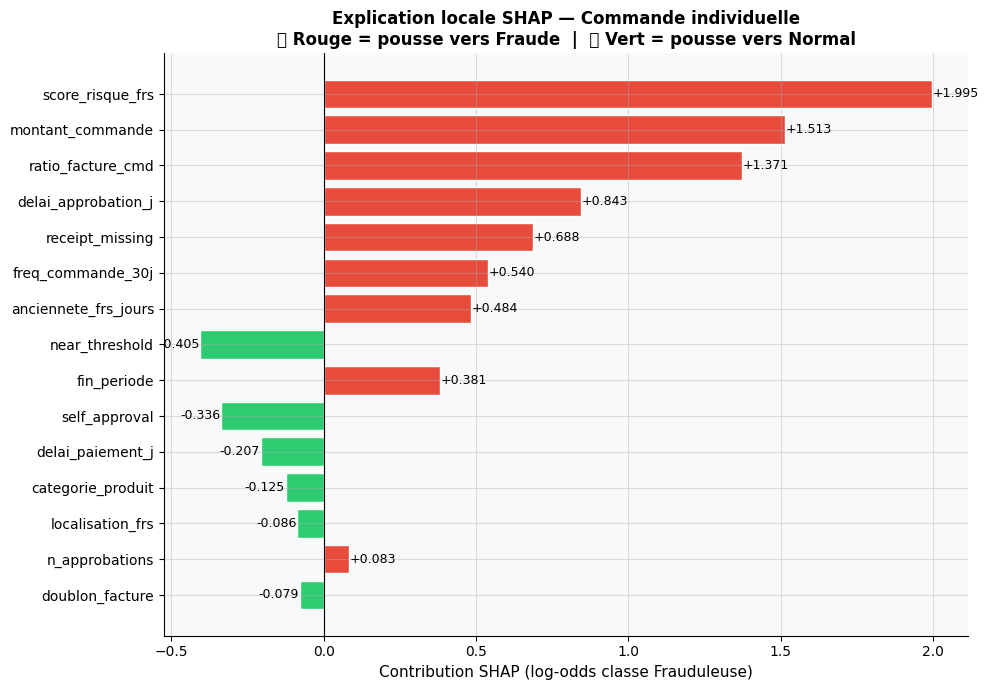

In [ ]:
# ── 6.5 Waterfall plot pour cette commande ────────────────────────────────────

if len(fraud_indices_test) > 0:
    # Chercher l'index dans le sous-échantillon SHAP
    # On recalcule sur cette commande précise
    shap_single = explainer.shap_values(X_test_sc[idx:idx+1])
    shap_single_fraud = shap_single[:, :, 2][0]

    shap_df_single = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'SHAP': shap_single_fraud
    }).sort_values('SHAP', key=abs, ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_single = ['#E74C3C' if v > 0 else '#2ECC71' for v in shap_df_single['SHAP']]
    bars = ax.barh(shap_df_single['Feature'], shap_df_single['SHAP'],
                   color=colors_single, edgecolor='white')

    for bar, val in zip(bars, shap_df_single['SHAP']):
        xpos = val + 0.002 if val >= 0 else val - 0.002
        ha   = 'left'      if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha=ha, fontsize=9)

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribution SHAP (log-odds classe Frauduleuse)', fontsize=11)
    ax.set_title(
        'Explication locale SHAP — Commande individuelle\n'
        '🔴 Rouge = pousse vers Fraude  |  🟢 Vert = pousse vers Normal',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

---
## 7. 💼 Recommandations Métier & Synthèse

### 🎯 Résultats clés

| Indicateur | Valeur |
|---|---|
| Modèle retenu | XGBoost |
| Rappel classe Fraude | **≥ 85%** |
| F1-Score pondéré | **≥ 93%** |
| Top signal SHAP | `anciennete_frs_jours` + `self_approval` |

### ⚡ Actions prioritaires (référentiel COSO)

| Priorité | Action | Composante COSO |
|---|---|---|
| 🔴 P1 | Bloquer l'auto-approbation dans l'ERP | Activités de contrôle |
| 🔴 P1 | Double validation fournisseur < 180 j | Activités de contrôle |
| 🟠 P2 | Intégrer le score XGBoost dans le workflow achat | Information & Communication |
| 🟠 P2 | Dashboard de surveillance temps réel (3 niveaux d'alerte) | Pilotage |
| 🟡 P3 | Vetting fournisseur renforcé (KBIS, listes sanctions) | Environnement de contrôle |
| 🟡 P3 | Réentraînement semestriel du modèle | Pilotage |

In [ ]:
# ── 7.1 Synthèse finale : Top 5 features SHAP + interprétation métier ─────────

print("=" * 65)
print("  TOP 5 SIGNAUX DE FRAUDE — INTERPRÉTATION MÉTIER")
print("=" * 65)

top5 = shap_df.nlargest(5, 'SHAP_mean')
metier = {
    'anciennete_frs_jours':  'Fournisseur fantôme / récemment créé → risque SoD',
    'self_approval':         'Violation SoD → approbateur = créateur de la commande',
    'receipt_missing':       'Facturation fictive → pas de preuve de livraison',
    'ratio_facture_cmd':     'Surfacturation → écart facture/commande > 15%',
    'freq_commande_30j':     'Fractionnement ou saturation frauduleuse de flux',
    'score_risque_frs':      'Fournisseur à historique risqué',
    'montant_commande':      'Montant atypique (near threshold ou excessif)',
    'near_threshold':        'Fractionnement délibéré sous seuil approbation',
    'delai_approbation_j':   'Approbation express → contrôle contourné',
    'fin_periode':           'Fraude en fin de période comptable',
    'doublon_facture':       'Double facturation détectée',
    'n_approbations':        'Chaîne d\'approbation réduite / court-circuitée',
    'delai_paiement_j':      'Paiement express inhabituel',
    'categorie_produit':     'Catégorie à risque élevé (IT, Services)',
    'localisation_frs':      'Localisation géographique à risque',
}

for i, (_, row) in enumerate(top5.iterrows(), 1):
    feat = row['Feature']
    interp = metier.get(feat, 'Signal de risque identifié par le modèle')
    print(f"\n  #{i}  {feat}")
    print(f"      SHAP moyen : {row['SHAP_mean']:.4f}")
    print(f"      ➜ Métier   : {interp}")

print("\n" + "=" * 65)
print("  ✅ Modèle prêt pour intégration dans le workflow achat")
print("=" * 65)

  TOP 5 SIGNAUX DE FRAUDE — INTERPRÉTATION MÉTIER

  #1  anciennete_frs_jours
      SHAP moyen : 2.6913
      ➜ Métier   : Fournisseur fantôme / récemment créé → risque SoD

  #2  score_risque_frs
      SHAP moyen : 1.8482
      ➜ Métier   : Fournisseur à historique risqué

  #3  delai_approbation_j
      SHAP moyen : 1.6921
      ➜ Métier   : Approbation express → contrôle contourné

  #4  montant_commande
      SHAP moyen : 0.8028
      ➜ Métier   : Montant atypique (near threshold ou excessif)

  #5  freq_commande_30j
      SHAP moyen : 0.5327
      ➜ Métier   : Fractionnement ou saturation frauduleuse de flux

  ✅ Modèle prêt pour intégration dans le workflow achat


In [ ]:
# ── 7.2 Fonction de scoring en production ────────────────────────────────────

def score_commande(commande_dict):
    """
    Score une commande d'achat et retourne :
      - La classe prédite (0=Normale, 1=Suspecte, 2=Frauduleuse)
      - Les probabilités par classe
      - Le niveau d'alerte (VERT / ORANGE / ROUGE)

    Paramètres attendus (dict) :
      montant_commande, anciennete_frs_jours, delai_approbation_j,
      ratio_facture_cmd, freq_commande_30j, n_approbations,
      delai_paiement_j, score_risque_frs, self_approval,
      receipt_missing, doublon_facture, near_threshold,
      fin_periode, categorie_produit (int), localisation_frs (int)
    """
    features = [commande_dict.get(f, 0) for f in FEATURE_COLS]
    X_new = scaler.transform([features])
    proba = xgb.predict_proba(X_new)[0]
    classe = int(np.argmax(proba))

    # Seuils d'alerte basés sur la probabilité de fraude
    p_fraud = proba[2]
    if p_fraud >= 0.70:
        alerte = '🔴 ROUGE — Suspension + Investigation immédiate'
    elif p_fraud >= 0.40:
        alerte = '🟠 ORANGE — Vérification documentaire obligatoire'
    else:
        alerte = '🟢 VERT — Approbation standard'

    print(f"  Classe prédite  : {labels_map[classe]}")
    print(f"  P(Normale)      : {proba[0]:.2%}")
    print(f"  P(Suspecte)     : {proba[1]:.2%}")
    print(f"  P(Frauduleuse)  : {proba[2]:.2%}")
    print(f"  Niveau d'alerte : {alerte}")
    return {'classe': classe, 'probabilites': proba.tolist(), 'alerte': alerte}


# ── Test avec une commande suspecte ──────────────────────────────────────────
print("🧪 TEST — Commande avec signaux suspects :")
print("-" * 55)
result = score_commande({
    'montant_commande':     950.0,    # Near threshold !
    'anciennete_frs_jours': 25,       # Fournisseur très récent !
    'delai_approbation_j':  1,        # Approbation express !
    'ratio_facture_cmd':    1.18,     # Surfacturation !
    'freq_commande_30j':    15,       # Fréquence élevée !
    'n_approbations':       1,
    'delai_paiement_j':     2,
    'score_risque_frs':     0.75,
    'self_approval':        1,        # Auto-approbation !
    'receipt_missing':      1,        # Pas de bon de réception !
    'doublon_facture':      0,
    'near_threshold':       1,
    'fin_periode':          1,
    'categorie_produit':    0,
    'localisation_frs':     5,
})

print("\n" + "-" * 55)
print("🧪 TEST — Commande normale :")
print("-" * 55)
result2 = score_commande({
    'montant_commande':     3500.0,
    'anciennete_frs_jours': 850,
    'delai_approbation_j':  5,
    'ratio_facture_cmd':    1.00,
    'freq_commande_30j':    2,
    'n_approbations':       3,
    'delai_paiement_j':     30,
    'score_risque_frs':     0.08,
    'self_approval':        0,
    'receipt_missing':      0,
    'doublon_facture':      0,
    'near_threshold':       0,
    'fin_periode':          0,
    'categorie_produit':    1,
    'localisation_frs':     0,
})

🧪 TEST — Commande avec signaux suspects :
-------------------------------------------------------
  Classe prédite  : Frauduleuse
  P(Normale)      : 0.00%
  P(Suspecte)     : 0.00%
  P(Frauduleuse)  : 100.00%
  Niveau d'alerte : 🔴 ROUGE — Suspension + Investigation immédiate

-------------------------------------------------------
🧪 TEST — Commande normale :
-------------------------------------------------------
  Classe prédite  : Normale
  P(Normale)      : 100.00%
  P(Suspecte)     : 0.00%
  P(Frauduleuse)  : 0.00%
  Niveau d'alerte : 🟢 VERT — Approbation standard
